In [1]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importing libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

In [24]:
# Read image from google drive
image_path = '/content/drive/MyDrive/EE655/Assignments/EE655_Assignment1_image.png'
img = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)

if img is None:
  raise ValueError("Image not found.")

In [25]:
# Define Prewitt kernels
priwitt_x = np.array([[-1,0,1],
                     [-1,0,1],
                     [-1,0,1]])

priwitt_y = np.array([[-1,-1,-1],
                      [0,0,0],
                      [1,1,1]])


In [26]:
# Apply priwitt filters
grad_x = cv2.filter2D(img,-1,priwitt_x)
grad_y = cv2.filter2D(img, -1, priwitt_y)

grad_x = grad_x.astype(np.int64)
grad_y = grad_y.astype(np.int64)

In [27]:
# gradient magnitude
grad_magnitude = np.sqrt(grad_x**2+grad_y**2)


In [28]:
# gradient angle
grad_angle = np.arctan2(grad_y,grad_x)

In [29]:
# edge map using otsu threshold
th = threshold_otsu(grad_magnitude)

edge_map = grad_magnitude > th

In [30]:
# elementwise multiplication
final_map = grad_angle * edge_map

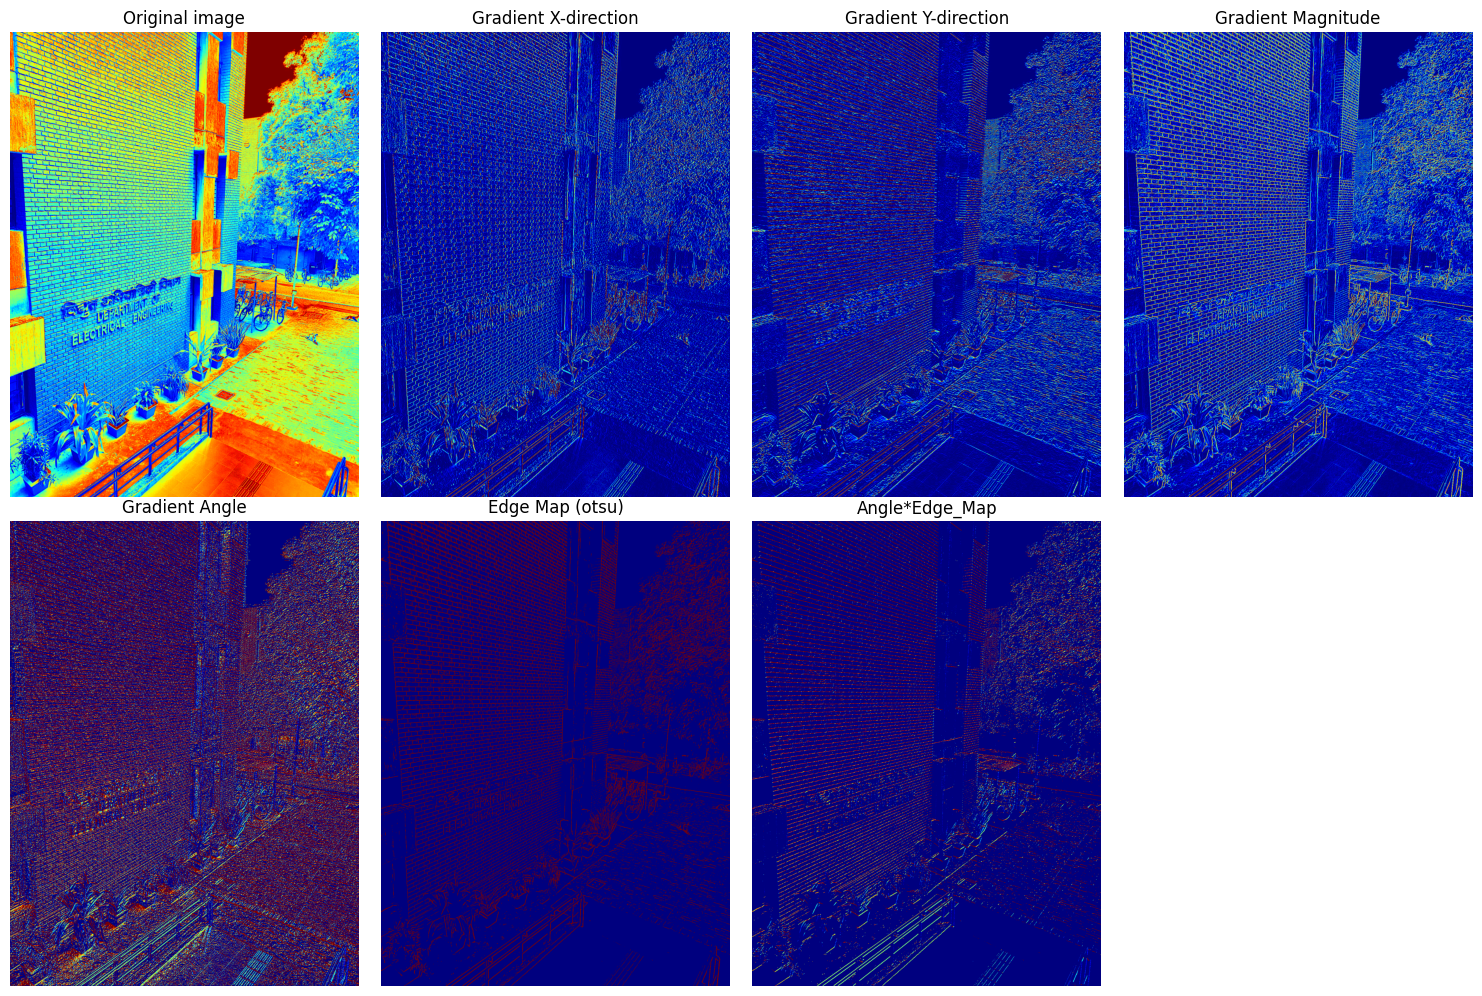

In [31]:
# visualisation using Jet colormap
titles = ['Original image','Gradient X-direction',
          'Gradient Y-direction','Gradient Magnitude',
          'Gradient Angle','Edge Map (otsu)','Angle*Edge_Map']

maps = [img, grad_x, grad_y, grad_magnitude, grad_angle, edge_map, final_map]

plt.figure(figsize=(15,10))

for i in range(len(maps)):
  plt.subplot(2,4,i+1)
  plt.imshow(maps[i],cmap='jet')
  plt.title(titles[i])
  plt.axis('off')

plt.tight_layout()
plt.show()
